In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

mpl.rcParams.update(
    {
        "axes.grid": True,
        # "axes.grid.which" : "both",
    }
)

# Use LaTeX fonts for better readability
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["Palatino"],
        "axes.labelsize": 12,
        "axes.titlesize": 14,
        "legend.fontsize": 10,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
    }
)

# Define custom colors
colors = {
    "inter_token_latency": "#1f77b4",  # Blue
    "expert_load_time": "#ff7f0e",  # Orange
    "base_tokens_per_sec": "#2ca02c",  # Green
    "tokens_with_experts_amortized": "#d62728",  # Red
    "tokens_with_experts_no_amortization": "#9467bd",  # Purple
}

# Model parameters
seq_len = 4096
hidden_dim = 3072
intermediate_dim = 12288
num_heads = 24
num_layers = 30
num_kv_heads = 2
vocab_size = 32000

# Bandwidths (GB/s converted to bytes/s)
flash_bandwidth = 4.2e9  # 2GB/s
lpddr_bandwidth = 85.6e9  # 10GB/s

# Base model parameter calculations
transformer_block_params = (
    (hidden_dim * intermediate_dim) * 2  # MLP weights
    + (hidden_dim * hidden_dim) * 2  # Attention projection weights
    + (hidden_dim * num_heads)  # Query weights
    + (hidden_dim * num_kv_heads * 2)  # Key and value weights
) * num_layers

bytes_per_param = 0.5

embedding_params = vocab_size * hidden_dim
base_model_params = transformer_block_params + embedding_params
base_model_size_bytes = (
    base_model_params * bytes_per_param
)  # Convert params to bytes (4-bit precision)

# Expert calculations
expert_rank = 128
expert_params_per_layer = (
    hidden_dim * expert_rank * 2
)  # Weight matrices for MLP per expert

k_values = np.arange(1, 65, 3)  # Range of k values

# Compute expert parameters across all layers
total_expert_params = k_values * expert_params_per_layer * num_layers
total_expert_size_bytes = total_expert_params * bytes_per_param

# Compute total model size including experts
total_model_sizes = base_model_size_bytes + total_expert_size_bytes

# Compute load times
base_model_load_time = base_model_size_bytes / lpddr_bandwidth
model_load_times_with_experts = total_model_sizes / lpddr_bandwidth
expert_load_times = total_expert_size_bytes / flash_bandwidth

# Compute tokens per second
base_tokens_per_second = 1 / base_model_load_time
equiv_dense_tokens_per_second = 1 / model_load_times_with_experts
tokens_per_second_amortized = 1 / (
    model_load_times_with_experts + (expert_load_times / 64)
)
tokens_per_second_no_amortization = 1 / (
    model_load_times_with_experts + expert_load_times
)

# Filter for total_expert_params <= 1.6B
mask = total_expert_params <= 0.6e9
filtered_total_expert_params = total_expert_params[mask]
filtered_model_load_times_with_experts = model_load_times_with_experts[mask]
filtered_equiv_dense_tokens_per_second = equiv_dense_tokens_per_second[mask]
filtered_expert_load_times = expert_load_times[mask]
filtered_tokens_per_second_amortized = tokens_per_second_amortized[mask]
filtered_tokens_per_second_no_amortization = tokens_per_second_no_amortization[mask]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3), dpi=300)
# Plot load times
ax1.plot(
    filtered_total_expert_params,
    filtered_model_load_times_with_experts,
    label="Peak ITL (LPDDR5x @ 85.6GB/s)",
    linestyle="--",
    color=colors["inter_token_latency"],
)
ax1.plot(
    filtered_total_expert_params,
    filtered_expert_load_times,
    label="Expert Load Time (Flash @ 4.2GB/s)",
    # marker="o",
    color=colors["expert_load_time"],
)

# Save load times plot as a PDF
ax1.set_xlabel("Active Expert Parameters")
ax1.set_ylabel("Time (s)")
ax1.set_ylim(0, 0.10)
ax1.set_title("Expert v.s. Model Loading Time", fontsize=12)
ax1.legend(loc="upper left")
ax1.grid(True)

# Save tokens per second plot as a PDF
# plt.plot(
#    filtered_total_expert_params,
#    [base_tokens_per_second] * len(filtered_total_expert_params),
#    label="Base Model",
#    linestyle="--",
#    color=colors["base_tokens_per_sec"],
# )
ax2.plot(
    filtered_total_expert_params,
    filtered_tokens_per_second_amortized,
    label="SLEs",
    linestyle="-",
    marker="o",
    markersize=5,
    linewidth=2,
    color=colors["tokens_with_experts_amortized"],
)
ax2.plot(
    filtered_total_expert_params,
    filtered_tokens_per_second_no_amortization,
    label="MoE",
    marker="s",
    markersize=5,
    linewidth=2,
    color=colors["tokens_with_experts_no_amortization"],
)
ax2.plot(
    filtered_total_expert_params,
    filtered_equiv_dense_tokens_per_second,
    label="Dense",
    linestyle="--",
    linewidth=2,
    color=colors["base_tokens_per_sec"],
)


ax2.set_xlabel("Active Expert Parameters")
ax2.set_ylabel("Tokens/s")
ax2.set_ylim(0)
ax2.set_title("MoE v.s. SLE Tokens/s", fontsize=12)
ax2.legend(loc="lower left")
ax2.grid(True)
plt.tight_layout()
plt.savefig("output/theoretical_perf_intro.pdf", format="pdf")
plt.close()


# Scaling figures

1. LR v.s. completion loss for MLP baseline, flop equiv mlp, full ft, routed_mlp, others?
2. load balancing loss + lflb weights v.s. loss

In [2]:
from functools import partial
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pprint import pprint


pretty_names = {
    "routed_mlp": "SLE",
    "routed_mlp_lblb": "SLE + Load Balancing Loss",
    "full_ft_noanneal": "Pre-training",
    "routed_mlp_lflb": "LBL weight=",
    "routed_mlp_zloss": "SLE + Router Z-Loss",
    "mlp_baseline": "Mem-Equiv MLP",
    "mlp_flopeq_baseline": "Flop-Equiv MLP",
}

markers = ["o", "s", "v", "^"]
df = pd.read_csv("wandb_output_1.csv")
all_tags = set(a.strip() for b in df["Tags"].unique() for a in b.split(","))
pprint(all_tags)
compare_tags = ["mlp_baseline", "mlp_flopeq_baseline", "full_ft_noanneal", "routed_mlp"]


def has_tag(row, tag):
    tags = row["Tags"].split(",")
    return tag.strip() in tags


def to_target_tag(compare_tags, row):
    tags = row["Tags"].split(",")
    for tag in tags:
        if tag.strip() in compare_tags:
            return pretty_names[tag.strip()]
    return "other"


routed_mlp = df[df.apply(lambda x: has_tag(x, "routed_mlp"), axis=1)]
routed_mlp_baseline = routed_mlp["eval/completion_loss (Min)"].min()

# Create a single figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(8, 6), dpi=300)
axes = axes.flatten()

# Subplot 1: Learning rate comparison
df_lr_compare = df.copy()
df_lr_compare["target_tag"] = df.apply(partial(to_target_tag, compare_tags), axis=1)
df_lr_compare = df_lr_compare[df_lr_compare["target_tag"] != "other"]
sns.lineplot(
    data=df_lr_compare,
    x="optimizer.learning_rate",
    y="eval/completion_loss (Min)",
    hue="target_tag",
    style="target_tag",
    markers=markers[: len(df_lr_compare["target_tag"].unique())],
    ax=axes[0],
)
axes[0].legend(loc="upper right")
axes[0].set_xscale("log")
low_x, up_x = axes[0].get_xlim()
low_y, up_y = axes[0].get_ylim()
axes[0].set_xlim(left=low_x, right=up_x * 3)
axes[0].set_ylim(bottom=low_y, top=up_y + 1e-3)
axes[0].get_legend().set_title(None)
axes[0].set_title("SLE v.s. Baselines")
axes[0].set_xlabel("Learning Rate")
axes[0].set_ylabel("Completion Loss")
axes[0].ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
# axes[0].grid(True, which="both")

# Subplot 2: LB Loss Weight
df_lbl = df.copy()
compare_tags = ["routed_mlp_lblb"]
df_lbl["target_tag"] = df.apply(partial(to_target_tag, compare_tags), axis=1)
df_lbl = df_lbl[df_lbl["target_tag"] != "other"]
df_lbl["rel_loss"] = df_lbl["eval/completion_loss (Min)"] - routed_mlp_baseline
sns.lineplot(
    data=df_lbl,
    x="lb_loss_weight",
    y="rel_loss",
    hue="target_tag",
    marker="o",
    ax=axes[1],
    legend=False,
)
axes[1].axhline(0, color="black", linestyle="--")
axes[1].set_xscale("log")
axes[1].set_title("Loss-Based Load Balancing")
axes[1].set_xlabel("LB Loss Weight")
axes[1].set_ylabel("Δ Completion Loss")
axes[1].ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

# Subplot 3: Expert Bias Update Rate
df_lflb = df.copy()
compare_tags = ["routed_mlp_lflb"]
df_lflb["target_tag"] = df.apply(partial(to_target_tag, compare_tags), axis=1)
df_lflb = df_lflb[df_lflb["target_tag"] != "other"]


def f_format(x):
    if x == 0.0:
        return "0"
    else:
        return np.format_float_scientific(x, precision=0, exp_digits=1, trim="-")


df_lflb["target_tag_lb"] = df_lflb["target_tag"] + df_lflb["lb_loss_weight"].map(
    f_format
)
df_lflb["rel_loss"] = df_lflb["eval/completion_loss (Min)"] - routed_mlp_baseline
sns.lineplot(
    data=df_lflb,
    x="model.expert_bias_update_rate",
    y="rel_loss",
    hue="target_tag_lb",
    style="target_tag_lb",
    markers=markers,
    ax=axes[2],
)
axes[2].get_legend().set_title(None)
axes[2].axhline(0, color="black", linestyle="--")
axes[2].set_xscale("log")
axes[2].set_title("Loss-Free Load Balancing")
axes[2].set_xlabel("Expert Bias Update Rate")
axes[2].set_ylabel("Δ Completion Loss")
axes[2].ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

# Subplot 4: Router Z Loss Weight
df_zloss = df.copy()
compare_tags = ["routed_mlp_zloss"]
df_zloss["target_tag"] = df.apply(partial(to_target_tag, compare_tags), axis=1)
df_zloss = df_zloss[df_zloss["target_tag"] != "other"]
df_zloss["rel_loss"] = df_zloss["eval/completion_loss (Min)"] - routed_mlp_baseline
sns.lineplot(
    data=df_zloss,
    x="router_z_loss_weight",
    y="rel_loss",
    hue="target_tag",
    marker="o",
    ax=axes[3],
    legend=False,
)
axes[3].axhline(0, color="black", linestyle="--")
axes[3].set_xscale("log")
axes[3].set_title("Router Z Loss Weight")
axes[3].set_xlabel("Router Z Loss Weight")
axes[3].set_ylabel("Δ Completion Loss")
axes[3].ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

# Adjust layout and save the figure
plt.tight_layout()
plt.savefig("output/merged_figure.pdf", format="pdf")
plt.close()


{'full_ft_completion',
 'full_ft_noanneal',
 'fullft_baseline',
 'hidden',
 'high_batch',
 'lora_baseline',
 'lora_noanneal',
 'mlp_baseline',
 'mlp_flopeq_baseline',
 'mlp_flopeq_scaling',
 'rerun',
 'routed_mlp',
 'routed_mlp_lblb',
 'routed_mlp_lblb_granularity',
 'routed_mlp_lblb_more_experts',
 'routed_mlp_lflb',
 'routed_mlp_lflb_granularity',
 'routed_mlp_lflb_more_experts',
 'routed_mlp_no_prefill_exp',
 'routed_mlp_scaling',
 'routed_mlp_zloss',
 'routed_mlp_zloss_scaling',
 'rstarcoder_sweep',
 'rstarcoder_will_sweep'}


/var/folders/p1/yn474z9j0v3_k6g9djbpnrn00000gn/T/ipykernel_59229/2608009266.py:111: UserWarning: The markers list has more values (4) than needed (2), which may not be intended.
  sns.lineplot(


### Scaling figures

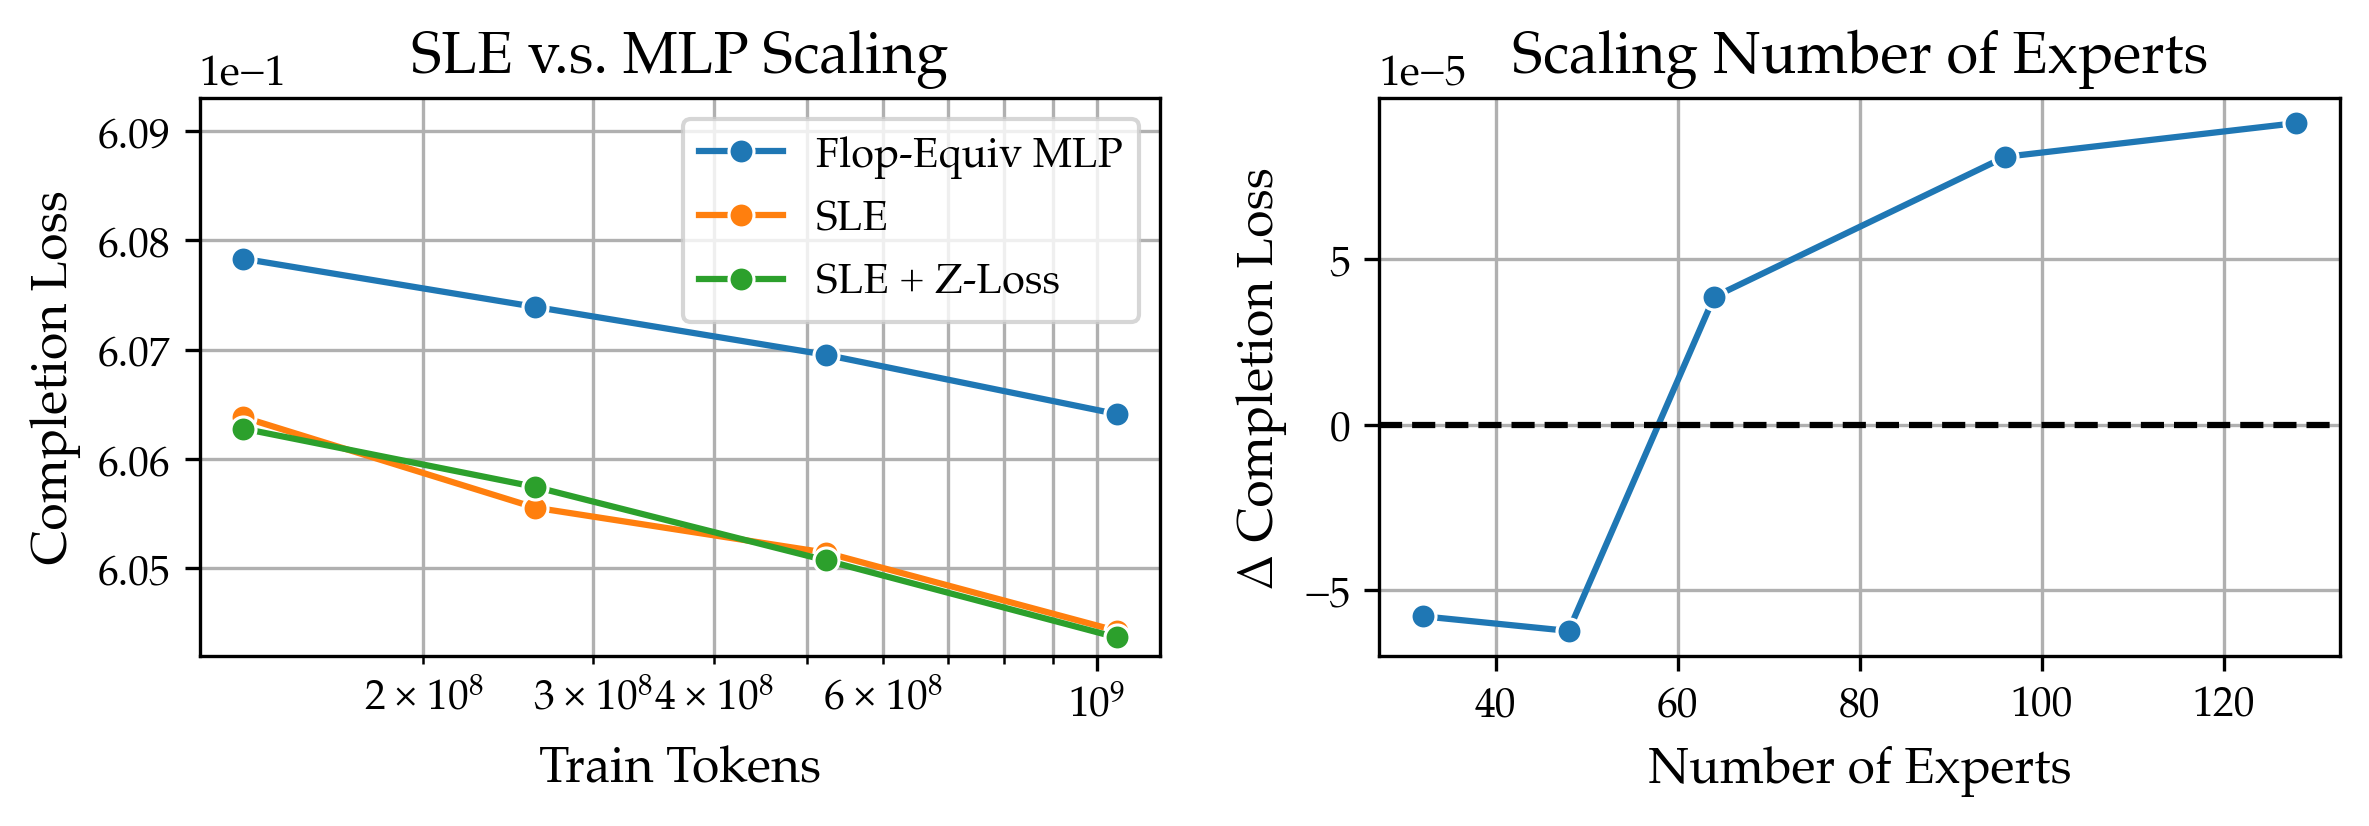

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from functools import partial

# ...existing code for df, to_target_tag, and routed_mlp_baseline...

fig, axes = plt.subplots(1, 2, figsize=(8, 3), dpi=300)

# First subplot: SLE vs. MLP Scaling
df_scaling = df.copy()
pretty_names = {
    "mlp_flopeq_scaling": "Flop-Equiv MLP",
    "routed_mlp_scaling": "SLE",
    "routed_mlp_zloss_scaling": "SLE + Z-Loss",
    "routed_mlp_lblb_more_experts": "SLE",
}


def get_scaling_tag(row):
    tags = row["Tags"].split(",")
    for tag in tags:
        if "scaling" in tag:
            return pretty_names[tag.strip()]
    return "other"


df_scaling["scaling_tag"] = df.apply(get_scaling_tag, axis=1)
df_scaling = df_scaling[df_scaling["scaling_tag"] != "other"]
ax1 = sns.lineplot(
    data=df_scaling,
    x="throughput/total_tokens",
    y="eval/completion_loss (Min)",
    hue="scaling_tag",
    marker="o",
    ax=axes[0],
)
ax1.set_xlabel("Train Tokens")
ax1.set_ylabel("Completion Loss")
ax1.get_legend().set_title(None)
ax1.ticklabel_format(axis="both", style="sci", scilimits=(0, 0))
ax1.set_xscale("log")
ax1.grid(True, which="both")
low_y, up_y = ax1.get_ylim()
ax1.set_ylim(bottom=low_y, top=up_y + 1.3e-3)
ax1.set_title("SLE v.s. MLP Scaling")

# Second subplot: Router Z-Loss Weight
df_moreexp = df.copy()
compare_tags = ["routed_mlp_lblb_more_experts"]
df_moreexp["target_tag"] = df.apply(partial(to_target_tag, compare_tags), axis=1)
df_moreexp = df_moreexp[df_moreexp["target_tag"] != "other"]
df_moreexp["rel_loss"] = df_moreexp["eval/completion_loss (Min)"] - routed_mlp_baseline
ax2 = sns.lineplot(
    data=df_moreexp,
    x="model.num_experts",
    y="rel_loss",
    hue="target_tag",
    marker="o",
    ax=axes[1],
)
ax2.axhline(0, color="black", linestyle="--")
ax2.set_xlabel("Number of Experts")
ax2.set_ylabel("Δ Completion Loss")
ax2.set_title("Scaling Number of Experts")
ax2.get_legend().remove()
ax2.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

# Adjust layout and save the figure
plt.tight_layout()
plt.savefig("output/combined_scaling_plots.pdf", format="pdf", bbox_inches="tight")


## Downstreams

/var/folders/p1/yn474z9j0v3_k6g9djbpnrn00000gn/T/ipykernel_59229/938547446.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/var/folders/p1/yn474z9j0v3_k6g9djbpnrn00000gn/T/ipykernel_59229/938547446.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/var/folders/p1/yn474z9j0v3_k6g9djbpnrn00000gn/T/ipykernel_59229/938547446.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


Saved plot to outputs/humaneval.pdf


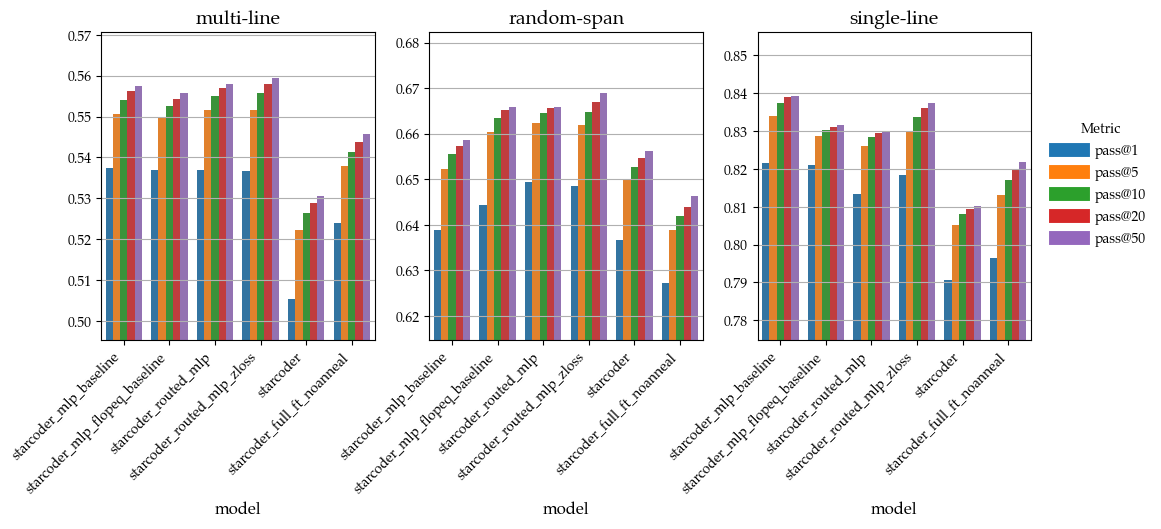

In [ ]:
# HumanEval

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load results from CSV
df = pd.read_csv("humaneval_results.csv")

# Prepare data for seaborn
prefixes = sorted(set(col.split(":")[0] for col in df.columns if col != "model"))
plot_data = []

for prefix in prefixes:
    cols = [col for col in df.columns if col.startswith(prefix)]
    for model in df['model']:
        for col in cols:
            plot_data.append({
                'model': model,
                'prefix': prefix,
                'metric': col.split(":")[1],
                'value': df.loc[df['model'] == model, col].values[0]
            })

plot_df = pd.DataFrame(plot_data)

# Plotting with seaborn
fig, axes = plt.subplots(1, len(prefixes), figsize=(12, 4), sharey=False)

colors = plt.cm.tab10.colors
color_map = {metric: colors[i % len(colors)] for i, metric in enumerate(plot_df['metric'].unique())}

for ax, prefix in zip(axes, prefixes):
    sns.barplot(
        data=plot_df[plot_df['prefix'] == prefix],
        x='model',
        y='value',
        hue='metric',
        palette=color_map,
        ax=ax
    )
    ax.set_title(prefix)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    min_y = plot_df[plot_df['prefix'] == prefix]['value'].min() * 0.98
    max_y = plot_df[plot_df['prefix'] == prefix]['value'].max() * 1.02
    ax.set_ylim(bottom=min_y, top=max_y)
    ax.legend_.remove()
    ax.set_ylabel(None)

# Save to PDF
fig.legend(
    handles=[plt.Line2D([0], [0], color=color_map[m], lw=10) for m in color_map],
    labels=list(color_map.keys()),
    title="Metric",
    loc="center left",
    bbox_to_anchor=(0.91, 0.5),
    frameon=False
)
#plt.tight_layout(rect=[0, 0, 0.83, 1])
plt.savefig("outputs/humaneval.pdf")
#plt.bclose()
print("Saved plot to outputs/humaneval.pdf")


In [ ]:
pretty_names = {
    "starcoder_mlp_baseline": "Mem-Equiv MLP",
    "starcoder_mlp_flopeq_baseline": "Flop-Equiv MLP",
    "starcoder_routed_mlp": "SLE",
    "starcoder_routed_mlp_zloss": "SLE + Z-Loss",
    "starcoder": "Base Model",
    "starcoder_full_ft_noanneal": "Pre-training",
}
df["pretty_model"] = df["model"].apply(lambda x: pretty_names[x])
bench_dfs = {}
passes = set([col.split(":")[1] for col in df.columns if ":" in col])
benches = set([col.split(":")[0] for col in df.columns if ":" in col])
other_cols = [col for col in df.columns if ":" not in col]
for bench in benches:
    rename_cols = {col: col.split(":")[1] for col in df.columns if col.startswith(bench)}
    bench_dfs[bench] = df[[col for col in df.columns if col.startswith(bench)] + other_cols].rename(columns=rename_cols)

bench_dfs["random-span"]["pretty_model"]

0     Mem-Equiv MLP
1    Flop-Equiv MLP
2               SLE
3      SLE + Z-Loss
4        Base Model
5      Pre-training
Name: pretty_model, dtype: object

/var/folders/p1/yn474z9j0v3_k6g9djbpnrn00000gn/T/ipykernel_59229/2160575314.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center")
/var/folders/p1/yn474z9j0v3_k6g9djbpnrn00000gn/T/ipykernel_59229/2160575314.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center")
/var/folders/p1/yn474z9j0v3_k6g9djbpnrn00000gn/T/ipykernel_59229/2160575314.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center")


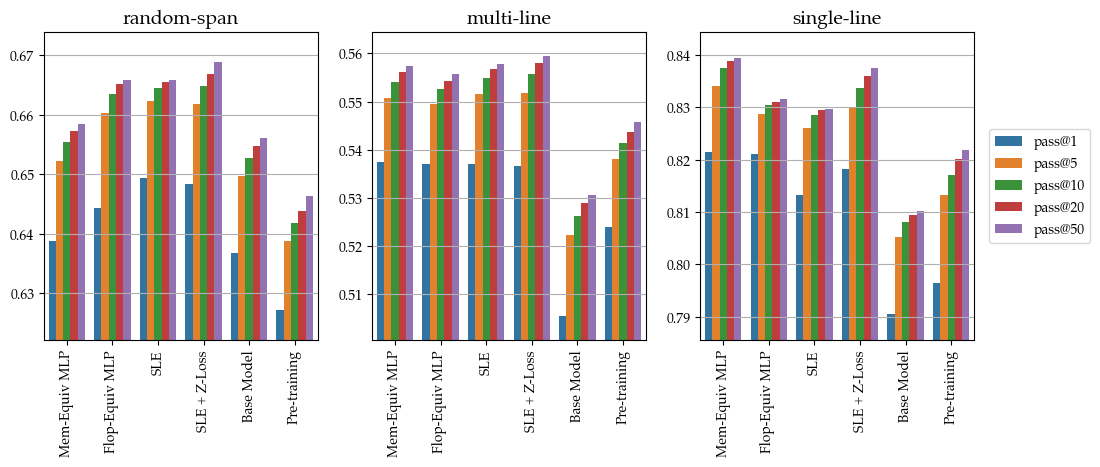

In [54]:
fig, axes = plt.subplots(1, len(bench_dfs), figsize=(4 * len(bench_dfs), 4), sharey=False)
colors = plt.cm.tab10.colors
for ax, (bench, bench_df) in zip(axes, bench_dfs.items()):
    melted = bench_df.melt(id_vars=other_cols, var_name="metric", value_name="value")
    sns.barplot(data=melted, x="pretty_model", y="value", hue="metric", palette=colors, ax=ax)
    ax.set_title(bench)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center")
    min_y = melted["value"].min() - 0.005
    max_y = melted["value"].max() + 0.005
    ax.set_ylim(bottom=min_y, top=max_y)
    ax.set_ylabel(None)
    ax.set_xlabel(None)
    ax.legend_.remove()
axes[-1].legend(bbox_to_anchor=(1.03, 0.5), loc='center left')

In [83]:
melted_dfs = {}
for d in bench_dfs:
    melted_dfs[d] = bench_dfs[d].melt(id_vars=other_cols, var_name="metric", value_name="value")
    melted_dfs[d]["pass"] = melted_dfs[d]["metric"].apply(lambda x: x.split("@")[1]).astype(int)

pretty_task_names = {
    "random-span": "Random Span",
    "multi-line": "Multi-Line",
    "single-line": "Single-Line"
}
fig, axs = plt.subplots(1, len(melted_dfs), figsize=(len(melted_dfs)*3, 3), dpi=300)
for ax, (bench, melted) in zip(axs, melted_dfs.items()):
    sns.lineplot(data=melted, x="pass", y="value", hue="pretty_model", style="pretty_model", markers=True, markersize=7, ax=ax, alpha=0.7)
    ax.set_title(pretty_task_names[bench])
    ax.set_xscale('log')
    ax.set_ylabel(None)
    ax.set_xlabel(None)
    ax.legend_.remove()
axs[-1].legend(loc='center left', bbox_to_anchor=(1.03, 0.5))
axs[1].set_xlabel("k")
axs[0].set_ylabel("pass@k")
plt.tight_layout()
plt.savefig("output/humaneval_bench.pdf", format="pdf")
plt.close()
#sns.lineplot(data=rs, x="pass", y="value", hue="pretty_model", style="pretty_model", markers=True, markersize=4)
#plt.xscale('log')